# 07 — Feature Fusion: S2 + S1 Training Samples

**Author:** Florian Klaver

**Prerequisite:** Notebook 04 must have run and produced files in `data/features_s1/`.

---

## What this notebook does

Merges the existing Sentinel-2 pixel samples with Sentinel-1 SAR feature values to produce
the 26-feature fusion training dataset.

**Strategy:** Instead of re-running the full pixel sampling loop, we reuse the existing
`training_samples_all_indices.csv` (which already contains `x`, `y` geographic coordinates
in EPSG:2056) and look up S1 feature values at those exact coordinates using `rasterio.sample()`.

### Feature sets

| Dataset | Features | Source |
|---|---|---|
| S2 features | 20 (5 indices × 4: after + diff, 5 raw bands × 2) | `training_samples_all_indices.csv` |
| SAR features | 6 (vv/vh/cr × after + diff) | `data/features_s1/<match_id>_s1_features.tif` |
| **Fusion** | **26** | **`training_samples_fusion.csv`** |

### Fair comparison design

Events without S1 coverage are **dropped** (not imputed) so all three model configs
(S2-only, S1-only, S2+S1 fusion) train and test on the **exact same set of events**.
This makes the performance comparison in notebook 06 fair.

---
## 1. Setup

In [1]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import rasterio

sys.path.insert(0, os.path.abspath('..'))
from src.config import *

S2_SAMPLES_PATH  = SAMPLES_S2_CSV
FEATURES_S1_DIR  = S1_FEATURES_DIR
COH_DIR          = COH_DIR
FUSION_OUT_PATH  = SAMPLES_FUSION_CSV       # SAR only (26 features)
COH_OUT_PATH     = SAMPLES_FUSION_COH_CSV   # SAR + coherence (30 features)
TEMPORAL_MATCHES = TEMPORAL_MATCHES_CSV

SAR_BAND_NAMES  = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
COH_BAND_NAMES  = ['coh_vv', 'coh_vh']           # per-sample coherence (period-matched)
COH_JUMP_NAMES  = ['coh_vv_jump', 'coh_vh_jump'] # event-level coherence change

s2_df = pd.read_csv(S2_SAMPLES_PATH)
print(f'S2 samples loaded:  {len(s2_df)} rows')
print(f'Columns:            {list(s2_df.columns)}')
print(f'Unique match_ids:   {s2_df["match_id"].nunique()}')
print(f'Class balance:      {s2_df["label"].value_counts().to_dict()}')

S2 samples loaded:  33368 rows
Columns:            ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir_after']
Unique match_ids:   63
Class balance:      {1: 18077, 0: 15291}


---
## 2. Check S1 Feature File Availability

In [2]:
# Discover which match_ids have S1 feature files on disk
s1_feature_files = glob.glob(os.path.join(FEATURES_S1_DIR, '*_s1_features.tif'))
available_match_ids = {
    int(os.path.basename(f).split('_')[0]) for f in s1_feature_files
}

all_match_ids = set(s2_df['match_id'].unique())
covered       = all_match_ids & available_match_ids
missing       = all_match_ids - available_match_ids

print(f'match_ids in S2 training CSV: {len(all_match_ids)}')
print(f'match_ids with S1 features:  {len(covered)}')
print(f'match_ids missing S1:        {len(missing)}')

if missing:
    print(f'\nDropped match_ids: {sorted(missing)}')
    print('These events had no S1 coverage (no ascending IW image within ±3 days).')

match_ids in S2 training CSV: 63
match_ids with S1 features:  63
match_ids missing S1:        0


---
## 3. Attach S1 Features to S2 Pixel Samples

For each match_id with an S1 feature file, we use `rasterio.DatasetReader.sample()` to
look up the 6 SAR band values at the exact geographic `(x, y)` coordinates from the S2
training CSV. This is exact — no resampling — because the S1 feature rasters were aligned
to the same grid as the S2 tiles in notebook 04.

In [3]:
# Work only on events that have S1 coverage
s2_covered = s2_df[s2_df['match_id'].isin(covered)].copy().reset_index(drop=True)
print(f'Pixel samples to enrich with SAR features: {len(s2_covered)}')

# Initialise SAR columns with NaN
for col in SAR_BAND_NAMES:
    s2_covered[col] = np.nan

n_processed = 0
n_nan_pixels = 0

for match_id in sorted(covered):
    feat_path = os.path.join(FEATURES_S1_DIR, f'{match_id}_s1_features.tif')
    mask = s2_covered['match_id'] == match_id
    rows = s2_covered.loc[mask]

    if len(rows) == 0:
        continue

    coords = list(zip(rows['x'], rows['y']))  # list of (lon, lat) in EPSG:2056

    with rasterio.open(feat_path) as src:
        # sample() returns an iterator of arrays, one per coordinate, shape (n_bands,)
        sampled = np.array(list(src.sample(coords)))  # shape: (n_pixels, 6)

    # Replace nodata sentinel (NaN already used, but also check for extreme values)
    sampled = sampled.astype(np.float32)
    sampled[sampled < -60] = np.nan

    for i, col in enumerate(SAR_BAND_NAMES):
        s2_covered.loc[mask, col] = sampled[:, i]

    n_nan_pixels += np.isnan(sampled).any(axis=1).sum()
    n_processed  += len(rows)

print(f'Pixels processed:         {n_processed}')
print(f'Pixels with any NaN SAR:  {n_nan_pixels}  ({n_nan_pixels/n_processed*100:.1f}%)')
print('\nSAR feature statistics:')
print(s2_covered[SAR_BAND_NAMES].describe().round(3))

Pixel samples to enrich with SAR features: 33368
Pixels processed:         33368
Pixels with any NaN SAR:  0  (0.0%)

SAR feature statistics:
        vv_after   vh_after   cr_after    vv_diff    vh_diff    cr_diff
count  33368.000  33368.000  33368.000  33368.000  33368.000  33368.000
mean     -13.723    -19.844     -6.121     -0.512     -0.295      0.217
std        1.607      1.505      1.380      1.794      1.562      1.653
min      -18.585    -24.455    -18.321    -18.752     -6.491     -7.559
25%      -14.752    -20.881     -6.959     -1.714     -1.305     -0.785
50%      -13.852    -19.928     -6.057     -0.570     -0.215      0.211
75%      -12.828    -18.894     -5.207      0.579      0.761      1.271
max        0.261     -7.295     -1.275      7.199      8.113     15.567


---
## 4. Attach Coherence Features

### Feature design rationale

The existing S2 and GRD features follow a **per-sample, period-matched** design:

| Sample type | Period | Example feature |
|------------|--------|-----------------|
| Positive (mowed, label=1) | t2 → t3 | `ndvi_diff` = NDVI(t3) − NDVI(t2) |
| Negative (not mowed, label=0) | t1 → t2 | `ndvi_diff` = NDVI(t2) − NDVI(t1) |

Each sample type receives feature values from **its own time interval**, giving the model
per-pixel discriminative signal (mowed pixels show a large NDVI drop, unmowed do not).

Coherence must follow the same logic to be useful:

| Sample type | Coherence pair | Feature assigned |
|------------|----------------|-----------------|
| Positive (mowed, label=1) | coh(t2, t3) — `coh_after` | `coh_vv`, `coh_vh` = values from `coh_after.tif` |
| Negative (not mowed, label=0) | coh(t1, t2) — `coh_before` | `coh_vv`, `coh_vh` = values from `coh_before.tif` |

This is distinct from the coherence **jump** (`coh_after − coh_before`), which describes
how coherence changed over the whole event window. The jump is the same value for positive
and negative samples from the same event (we would need a 4th SLC scene at t0 to compute
an equivalent negative-sample jump). It is kept as an **event-level context feature** —
if the jump is large and positive, it corroborates that mowing happened somewhere in the scene.

**4 coherence features in total:**
- `coh_vv`, `coh_vh` — per-sample VV/VH coherence for that sample's own time interval
- `coh_vv_jump`, `coh_vh_jump` — event-level VV/VH coherence change (same for ± samples)

Events without coherence files on disk (nb08 not yet run for them) receive NaN and remain
in the dataset. Notebook 05 handles the coherence-eligible subset separately.

In [4]:
def _find_coh_bands(src):
    """
    Return (vv_idx, vh_idx) as 1-based band indices for coherence bands.
    SNAP's GeoTIFF writer omits band descriptions, so fall back to a multi-region
    value-range scan: coherence is always in [0, 1]; interferogram bands are not.
    """
    descs = src.descriptions or []
    named = [(i + 1, d) for i, d in enumerate(descs) if d and 'coh' in d.lower()]
    vv = next((i for i, d in named if 'vv' in d.lower()), None)
    vh = next((i for i, d in named if 'vh' in d.lower()), None)
    if vv is not None:
        return vv, vh

    h, w, sz = src.height, src.width, 200
    wins = [
        rasterio.windows.Window(0, 0, min(sz, w), min(sz, h)),
        rasterio.windows.Window(max(0, w // 2 - sz // 2), max(0, h // 2 - sz // 2), min(sz, w), min(sz, h)),
        rasterio.windows.Window(max(0, w - sz), max(0, h - sz), min(sz, w), min(sz, h)),
    ]
    coh_idx = []
    for band in range(1, src.count + 1):
        ok = True
        for win in wins:
            arr   = src.read(band, window=win).astype(float)
            valid = arr[(arr != 0) & np.isfinite(arr)]
            if valid.size > 50 and (valid.max() > 1.0 or valid.min() < 0.0):
                ok = False
                break
        if ok:
            coh_idx.append(band)
    if len(coh_idx) >= 2:
        return coh_idx[0], coh_idx[1]
    if len(coh_idx) == 1:
        return coh_idx[0], None
    return 1, (2 if src.count >= 2 else None)


# ── Discover available coherence pairs ───────────────────────────────────────
coh_before_ids = {int(os.path.basename(f).split('_')[0])
                  for f in glob.glob(os.path.join(COH_DIR, '*_coh_before.tif'))}
coh_after_ids  = {int(os.path.basename(f).split('_')[0])
                  for f in glob.glob(os.path.join(COH_DIR, '*_coh_after.tif'))}
coh_available  = coh_before_ids & coh_after_ids

n_all = s2_covered['match_id'].nunique()
print(f'Events with both coherence rasters on disk: {len(coh_available)} / {n_all}')
print(f'Events without coherence (will be NaN):     {n_all - len(coh_available)}')

# Initialise coherence columns with NaN
for col in COH_BAND_NAMES + COH_JUMP_NAMES:
    s2_covered[col] = np.nan

n_coh_ok = 0

for match_id in sorted(coh_available):
    before_path = os.path.join(COH_DIR, f'{match_id}_coh_before.tif')
    after_path  = os.path.join(COH_DIR, f'{match_id}_coh_after.tif')

    mask = s2_covered['match_id'] == match_id
    rows = s2_covered.loc[mask]
    if len(rows) == 0:
        continue

    coords = list(zip(rows['x'], rows['y']))

    # Sample both rasters at every pixel coordinate
    with rasterio.open(before_path) as bs:
        vv_b, vh_b = _find_coh_bands(bs)
        coh_b = np.array(list(bs.sample(coords))).astype(float)   # (n_pixels, n_bands)
    with rasterio.open(after_path) as as_:
        vv_a, vh_a = _find_coh_bands(as_)
        coh_a = np.array(list(as_.sample(coords))).astype(float)

    # Extract VV and VH from each raster (convert 1-based idx → 0-based column)
    b_vv = coh_b[:, vv_b - 1].copy()
    b_vh = coh_b[:, vh_b - 1].copy() if vh_b else np.full(len(rows), np.nan)
    a_vv = coh_a[:, vv_a - 1].copy()
    a_vh = coh_a[:, vh_a - 1].copy() if vh_a else np.full(len(rows), np.nan)

    # Replace SNAP nodata (0 for pixels outside SAR coverage)
    for arr in [b_vv, b_vh, a_vv, a_vh]:
        arr[arr <= 0] = np.nan

    labels = rows['label'].values

    # Period-matched coherence: label=1 uses coh_after, label=0 uses coh_before
    s2_covered.loc[mask, 'coh_vv'] = np.where(labels == 1, a_vv, b_vv)
    s2_covered.loc[mask, 'coh_vh'] = np.where(labels == 1, a_vh, b_vh)

    # Event-level coherence jump (same value for positive and negative samples)
    s2_covered.loc[mask, 'coh_vv_jump'] = a_vv - b_vv
    s2_covered.loc[mask, 'coh_vh_jump'] = a_vh - b_vh

    n_coh_ok += len(rows)

print(f'\nPixels enriched with coherence: {n_coh_ok}')
if n_coh_ok > 0:
    coh_rows = s2_covered[s2_covered['coh_vv'].notna()]
    print('\nCoherence feature stats:')
    print(coh_rows[COH_BAND_NAMES + COH_JUMP_NAMES].describe().round(3))
    print('\nMean by class (label 1=mowed, 0=not mowed):')
    print(coh_rows.groupby('label')[COH_BAND_NAMES + COH_JUMP_NAMES].mean().round(3))

Events with both coherence rasters on disk: 45 / 63
Events without coherence (will be NaN):     18

Pixels enriched with coherence: 17609

Coherence feature stats:
          coh_vv     coh_vh  coh_vv_jump  coh_vh_jump
count  17609.000  17609.000    17609.000    17609.000
mean       0.265      0.297       -0.011       -0.035
std        0.141      0.148        0.164        0.172
min        0.014      0.014       -0.617       -0.604
25%        0.157      0.183       -0.118       -0.151
50%        0.244      0.283       -0.010       -0.033
75%        0.357      0.393        0.097        0.080
max        0.913      0.952        0.623        0.578

Mean by class (label 1=mowed, 0=not mowed):
       coh_vv  coh_vh  coh_vv_jump  coh_vh_jump
label                                          
0       0.268   0.311       -0.003       -0.035
1       0.263   0.283       -0.019       -0.034


---
## 5. Drop Rows with NaN SAR Features

Pixels where the GRD S1 raster has nodata (water, shadow, masked edges) must be dropped — the ML models cannot accept NaN inputs for SAR features.

Coherence NaNs are **not** dropped here. Notebook 08 will select only the coherence-eligible subset for the coherence ablation configs.

In [6]:
before_drop = len(s2_covered)
fusion_df = s2_covered.dropna(subset=SAR_BAND_NAMES).reset_index(drop=True)
after_drop = len(fusion_df)

print(f'Before NaN drop: {before_drop} rows')
print(f'After NaN drop:  {after_drop} rows  ({before_drop - after_drop} dropped)')
print(f'Retained:        {after_drop/before_drop*100:.1f}%')
print()
print(f'Final class balance: {fusion_df["label"].value_counts().to_dict()}')
print(f'Events covered:      {fusion_df["match_id"].nunique()}')

Before NaN drop: 33368 rows
After NaN drop:  33368 rows  (0 dropped)
Retained:        100.0%

Final class balance: {1: 18077, 0: 15291}
Events covered:      63


---
## 6. Save Fusion Datasets

Two files are written:
- **`training_samples_fusion.csv`** — 26 features (S2 + GRD SAR), backwards-compatible with existing nb05 runs
- **`training_samples_fusion_coh.csv`** — 30 features (+ 4 coherence), used for the coherence ablation in nb05

In [7]:
# Save backwards-compatible SAR fusion (drop coherence columns so nb05 existing runs are unaffected)
sar_cols = [c for c in fusion_df.columns if c not in COH_BAND_NAMES + COH_JUMP_NAMES]
fusion_df[sar_cols].to_csv(FUSION_OUT_PATH, index=False)
print(f'Saved (SAR fusion):')
print(f'  Path:    {FUSION_OUT_PATH}')
print(f'  Rows:    {len(fusion_df)}')
print(f'  Columns: {sar_cols}')

# Save coherence-extended fusion
fusion_df.to_csv(COH_OUT_PATH, index=False)
coh_cols = list(fusion_df.columns)
print(f'\nSaved (coherence fusion):')
print(f'  Path:    {COH_OUT_PATH}')
print(f'  Rows:    {len(fusion_df)}')
print(f'  Columns ({len(coh_cols)}): {coh_cols}')
n_with_coh = fusion_df['coh_vv'].notna().sum()
print(f'\n  Rows with coherence data: {n_with_coh} / {len(fusion_df)} '
      f'({n_with_coh/len(fusion_df)*100:.1f}%)')

Saved (SAR fusion):
  Path:    C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\training_samples_fusion.csv
  Rows:    33368
  Columns: ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir_after', 'vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']

Saved (coherence fusion):
  Path:    C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\training_samples_fusion_coh.csv
  Rows:    33368
  Columns (35): ['x', 'y', 'event_date', 'match_id', 'label', 'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after', 'ndvi_diff', 'evi_diff', 'savi_diff', 'gndvi_diff', 'ndii_diff', 'blue_diff', 'green_diff', 'red_diff', 'nir_diff', 'swir_diff', 'blue_after', 'green_after', 'red_after', 'nir_after', 'swir

---
## 6. Quick Feature Distribution Check

Sanity-check that SAR features separate mowed vs. not-mowed samples in the expected direction:
- `vh_diff` should be **more negative** for mowed pixels (VH drops after mowing)
- `cr_diff` should be **more negative** for mowed pixels (CR drops after mowing)

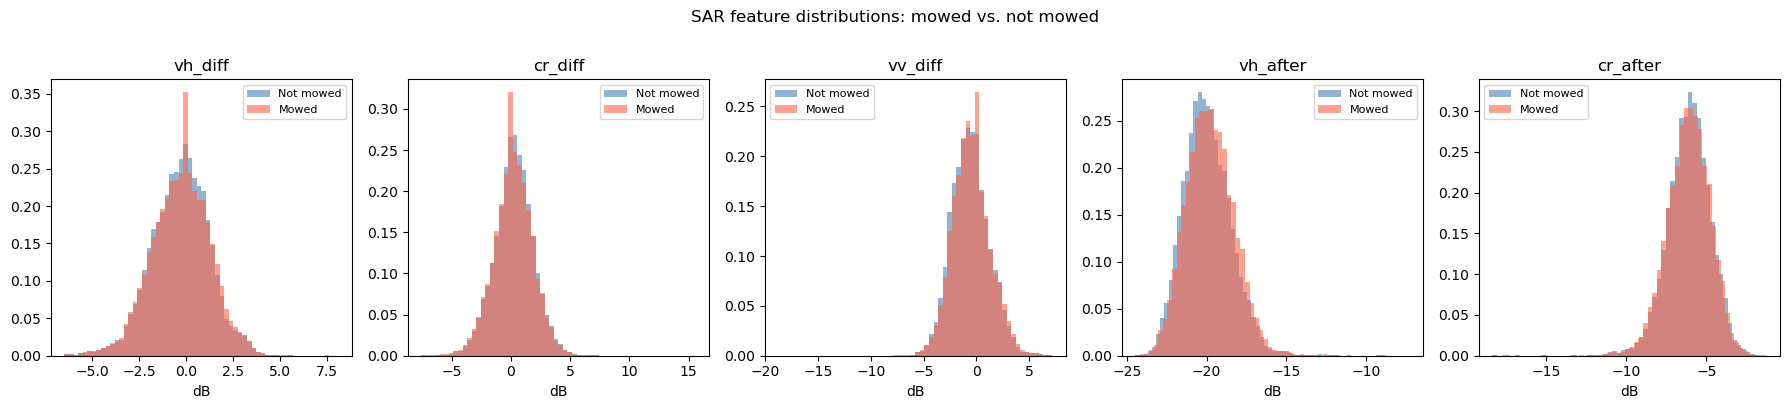

Expected: vh_diff and cr_diff should be shifted negative for mowed pixels.

Mean values by class:
       vh_diff  cr_diff  vv_diff  vh_after  cr_after
label                                               
0       -0.309    0.246   -0.555   -19.943    -6.118
1       -0.284    0.191   -0.475   -19.760    -6.125


In [8]:
import matplotlib.pyplot as plt

mowed     = fusion_df[fusion_df['label'] == 1]
not_mowed = fusion_df[fusion_df['label'] == 0]

key_features = ['vh_diff', 'cr_diff', 'vv_diff', 'vh_after', 'cr_after']

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))

for ax, feat in zip(axes, key_features):
    ax.hist(not_mowed[feat].dropna(), bins=60, alpha=0.6, label='Not mowed', color='steelblue', density=True)
    ax.hist(mowed[feat].dropna(),     bins=60, alpha=0.6, label='Mowed',     color='tomato',    density=True)
    ax.set_title(feat)
    ax.set_xlabel('dB')
    ax.legend(fontsize=8)

plt.suptitle('SAR feature distributions: mowed vs. not mowed', y=1.01)
plt.tight_layout()
plt.show()

print('Expected: vh_diff and cr_diff should be shifted negative for mowed pixels.')
print('\nMean values by class:')
print(fusion_df.groupby('label')[key_features].mean().round(3))

---
## Summary

**Outputs:**

`data/training_samples_fusion.csv` — 26 features (20 S2 + 6 GRD SAR)
- Backwards-compatible with existing nb05 configs (S2-only, S1-only, S2+S1 fusion)

`data/training_samples_fusion_coh.csv` — 30 features (+ 4 coherence)
- Adds `coh_vv`, `coh_vh` (per-sample, period-matched coherence) and
  `coh_vv_jump`, `coh_vh_jump` (event-level coherence change context)
- Events without coherence rasters on disk have NaN in these columns
- Re-run this notebook after completing nb08 batch processing to fill all events

**Coherence feature design (key point):**
`coh_vv` / `coh_vh` are period-matched: positive samples (label=1, mowing period t2→t3)
receive values from `coh_after.tif`; negative samples (label=0, non-mowing period t1→t2)
receive values from `coh_before.tif`. This mirrors the existing GRD design and gives the
model per-pixel discriminative signal from the correct time interval.

**Next step → notebook 05:** Train coherence ablation configs on `training_samples_fusion_coh.csv`,
selecting only rows where `coh_vv.notna()` for the coherence-inclusive configs.